In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.isna().sum()

,0
review,0
sentiment,0


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['review']=df['review'].str.lower()
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."


In [ ]:
def clean_text (text) :
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  return text
df['review']=df['review'].apply(clean_text)
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production br br the...
2,i thought this was a wonderful way to spend ti...
3,basically there s a family where a little boy ...
4,petter mattei s love in the time of money is...


In [ ]:
df['review'] = df['review'].str.split().str.join(' ')

In [ ]:
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stopwords.discard('no')
stopwords.discard('not')
stopwords.discard('never')

In [ ]:
def remove_stopwords (text):
  words = text.split()
  words = [word for word in words if word not in stopwords]
  return ' '.join(words)

In [ ]:
df['review']=df['review'].apply(remove_stopwords)
df['review'].head()

,review
0,one reviewers mentioned watching oz episode ho...
1,wonderful little production br br filming tech...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake thinks zombie...
4,petter mattei love time money visually stunnin...


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
x = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']
x.shape

(49582, 5000)

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)
acc_logistic = accuracy_score(y_test,y_pred)
print("Accuracy",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy 0.8904910759302208
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4939
    positive       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [ ]:
model_nb = MultinomialNB()
model_nb.fit(x_train,y_train)

MultinomialNB()

In [ ]:
y_pred_nb = model_nb.predict(x_test)
acc_nb = accuracy_score(y_test,y_pred_nb)
print("Accuracy",accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))

Accuracy 0.8591307855198145
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      4939
    positive       0.85      0.88      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



In [ ]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))

Logistic: 0.8904910759302208
Naive Bayes: 0.8591307855198145


In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])
x_seq = tokenizer.texts_to_sequences(df['review'])

In [ ]:
max_len = 100
x_pad = pad_sequences(x_seq,maxlen=max_len,padding='post')

In [ ]:
y = df['sentiment'].map({'positive':1,'negative':0}).values

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_pad,y,test_size=0.2,random_state=42)

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=10000,output_dim=128,input_length=max_len))

model.add(LSTM(32,return_sequences=True))
model.add(Dropout(0.5))

model.add(LSTM(16))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [ ]:
history = model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7342 - loss: 0.5530 - val_accuracy: 0.8238 - val_loss: 0.4479
Epoch 2/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8366 - loss: 0.4107 - val_accuracy: 0.6518 - val_loss: 0.5207
Epoch 3/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8695 - loss: 0.3247 - val_accuracy: 0.8559 - val_loss: 0.3496
Epoch 4/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9080 - loss: 0.2446 - val_accuracy: 0.8709 - val_loss: 0.3273
Epoch 5/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9305 - loss: 0.1954 - val_accuracy: 0.8712 - val_loss: 0.3318
Epoch 6/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9477 - loss: 0.1544 - val_accuracy: 0.8683 - val_loss: 0.3714
Epoch 7/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9613 - loss: 0.1180 - val_accuracy: 0.8641 - val_loss: 0.4423


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
acc_lstm = acc
print("Test Accuracy:", acc)

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8709 - loss: 0.3273
Test Accuracy: 0.8709287047386169


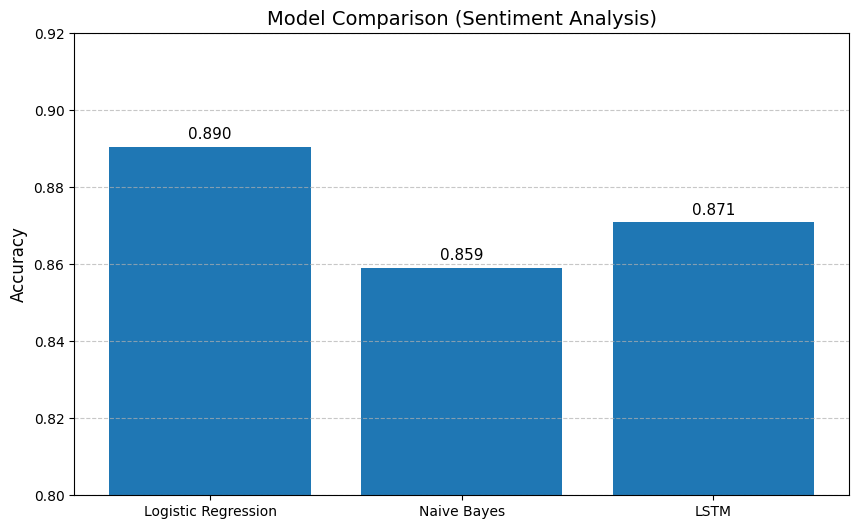

In [ ]:

models = ['Logistic Regression', 'Naive Bayes', 'LSTM']
scores = [acc_logistic, acc_nb, acc_lstm]

plt.figure(figsize=(10,6))

bars = plt.bar(models, scores)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
             f"{yval:.3f}", ha='center', fontsize=11)

plt.ylim(0.8, 0.92)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Comparison (Sentiment Analysis)", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
